# Time-of-Flight Damped Oscillation Fit
Load `ds_raw.h5` from a time-of-flight measurement and fit the trace with the `damped_oscillation` fitter.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data
from scqat.math_tools import get_fitter

## 1. Configuration

In [2]:
DATA_FOLDER = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\#2800_01b_time_of_flight_mw_fem_015354"
DS_RAW_PATH = os.path.join(DATA_FOLDER, "ds_raw.h5")

## 2. Load Dataset and Inspect Format

In [3]:
dataset = load_xarray_h5(DS_RAW_PATH)
dataset

<xarray.Dataset> Size: 208kB
Dimensions:          (readout_time: 4000, qubit: 1)
Coordinates:
  * readout_time     (readout_time) int32 16kB 0 1 2 3 4 ... 3996 3997 3998 3999
  * qubit            (qubit) object 8B 'q1'
Data variables:
    adcI             (qubit, readout_time) float64 32kB 0.1102 ... -0.001343
    adcQ             (qubit, readout_time) float64 32kB -0.05615 ... -0.0004297
    adc_single_runI  (qubit, readout_time) float64 32kB 0.115 ... -0.02588
    adc_single_runQ  (qubit, readout_time) float64 32kB -0.02686 ... -0.01587
    IQ_abs           (qubit, readout_time) float64 32kB 0.1237 ... 0.00141
    filtered_adc     (qubit, readout_time) float64 32kB 0.1257 ... 0.002136
    threshold        (qubit) float64 8B 0.02996
    delay            (qubit) float64 8B 0.0

In [4]:
# Split along the repetition (qubit) dimension and take the first entry
sq_data = repetition_data(dataset)[0]
sq_data

<xarray.Dataset> Size: 208kB
Dimensions:          (readout_time: 4000)
Coordinates:
  * readout_time     (readout_time) int32 16kB 0 1 2 3 4 ... 3996 3997 3998 3999
    qubit            <U2 8B 'q1'
Data variables:
    adcI             (readout_time) float64 32kB 0.1102 0.06452 ... -0.001343
    adcQ             (readout_time) float64 32kB -0.05615 -0.1125 ... -0.0004297
    adc_single_runI  (readout_time) float64 32kB 0.115 0.0481 ... -0.02588
    adc_single_runQ  (readout_time) float64 32kB -0.02686 -0.1301 ... -0.01587
    IQ_abs           (readout_time) float64 32kB 0.1237 0.1297 ... 0.00141
    filtered_adc     (readout_time) float64 32kB 0.1257 0.1276 ... 0.002136
    threshold        float64 8B 0.02996
    delay            float64 8B 0.0

## 3. Inspect Variables / Coordinates
Run this cell to see what data variables and coordinates are available before deciding
which trace to fit.

In [5]:
print("Data variables:", list(sq_data.data_vars))
print("Coordinates:   ", list(sq_data.coords))
print("Dims:          ", dict(sq_data.sizes))
print("Attrs:         ", dict(sq_data.attrs))

Data variables: ['adcI', 'adcQ', 'adc_single_runI', 'adc_single_runQ', 'IQ_abs', 'filtered_adc', 'threshold', 'delay']
Coordinates:    ['readout_time', 'qubit']
Dims:           {'readout_time': 4000}
Attrs:          {}


## 4. Build Magnitude Trace
Compute `|IQ| = sqrt(adcI^2 + adcQ^2)` along `readout_time`.

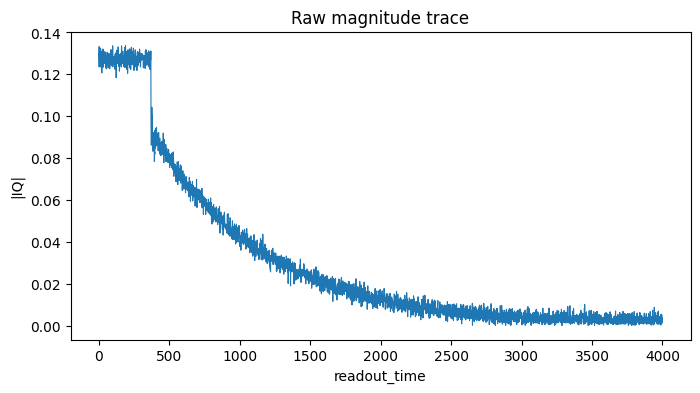

In [6]:
mag = np.sqrt(sq_data["adcI"] ** 2 + sq_data["adcQ"] ** 2)
mag.name = "IQ_mag"
t = mag.coords["readout_time"].values

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, mag.values, lw=0.8)
ax.set_xlabel("readout_time")
ax.set_ylabel("|IQ|")
ax.set_title("Raw magnitude trace")
plt.show()

## 5. Fit Exponential Decay
Model: `a * exp(-x / tau) + c`.

In [16]:
from lmfit import Model

def exp_decay(x, a, tau, c):
    return a * np.exp(-x / tau) + c

# x-range for the fit (inclusive)
FIT_X_MIN, FIT_X_MAX = 500, 2000

mask = (t >= FIT_X_MIN) & (t <= FIT_X_MAX)
t_fit = t[mask]
y_fit = mag.values[mask]

# Initial guesses (from the windowed data)
c0 = float(np.mean(y_fit[-max(10, len(y_fit) // 20):]))
a0 = float(y_fit[0] - c0)
# tau guess: time at which signal decays to ~1/e of initial deviation
target = c0 + a0 / np.e
try:
    idx = int(np.argmin(np.abs(y_fit - target)))
    tau0 = float(t_fit[idx] - t_fit[0]) if t_fit[idx] > t_fit[0] else float((t_fit[-1] - t_fit[0]) / 5)
except Exception:
    tau0 = float((t_fit[-1] - t_fit[0]) / 5)

model = Model(exp_decay)

params = model.make_params(a=a0, tau=tau0, c=c0)
params["tau"].set(min=1e-12)

result = model.fit(y_fit, params, x=t_fit)
print(result.fit_report())


[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 1501
    # variables        = 3
    chi-square         = 0.00834390
    reduced chi-square = 5.5700e-06
    Akaike info crit   = -18156.2664
    Bayesian info crit = -18140.3247
    R-squared          = 0.98445424
[[Variables]]
    a:    0.14639362 +/- 8.3121e-04 (0.57%) (init = 0.06570721)
    tau:  815.982550 +/- 12.0418528 (1.48%) (init = 735)
    c:   -8.5891e-05 +/- 5.2530e-04 (611.59%) (init = 0.01287431)
[[Correlations]] (unreported correlations are < 0.100)
    C(tau, c) = -0.9676
    C(a, tau) = -0.8204
    C(a, c)   = +0.6655


## 6. Plot Fit

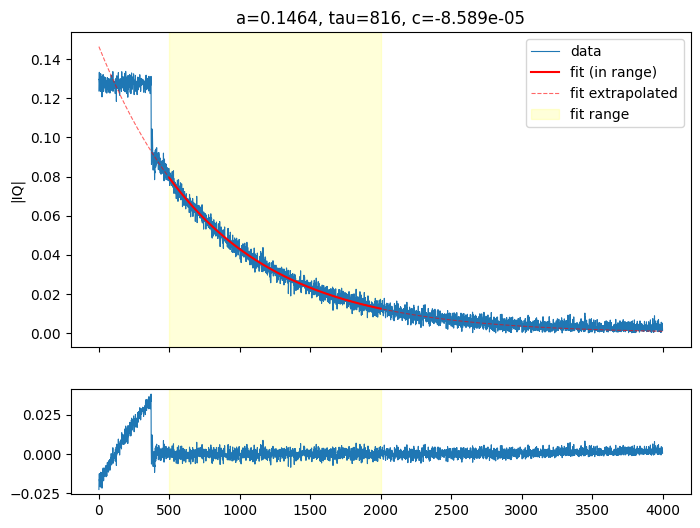

Text(4.444444444444452, 0.5, 'residual')

<Figure size 640x480 with 0 Axes>

In [17]:
# Evaluate the fit over the full trace for visualization
best_full = exp_decay(t, **result.best_values)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(t, mag.values, lw=0.8, label="data")
ax1.plot(t_fit, result.best_fit, "r-", lw=1.5, label="fit (in range)")
ax1.plot(t, best_full, "r--", lw=0.8, alpha=0.6, label="fit extrapolated")
ax1.axvspan(FIT_X_MIN, FIT_X_MAX, color="yellow", alpha=0.15, label="fit range")
ax1.set_ylabel("|IQ|")
ax1.legend()
ax1.set_title(
    f"a={result.params['a'].value:.4g}, "
    f"tau={result.params['tau'].value:.4g}, "
    f"c={result.params['c'].value:.4g}"
)

ax2.plot(t, mag.values - best_full, lw=0.8)

ax2.axvspan(FIT_X_MIN, FIT_X_MAX, color="yellow", alpha=0.15)
plt.show()

ax2.axhline(0, color="k", lw=0.5)
plt.tight_layout()

ax2.set_xlabel("readout_time")
ax2.set_ylabel("residual")